<font color="FF3B3B"><h1 align="left">Proyecto de aprendizaje profundo</h1></font>
<font color="#6E6E6E"><h2 align="left">Modelo complejo CNN Nº 4</h2></font>

##### David Alejandro Pedroza De Jesús
##### Joel Ezequiel Vicente Alonso

Cargamos las librerias para la realización del proyecto

In [1]:
import sys
sys.path.append("../")
from CNNComplejo import ModeloComplejo
import numpy as np
import pandas as pd
import cv2
import kagglehub
import os
from shutil import move
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
import seaborn as sns
from tensorflow.keras.utils import plot_model

c:\Users\Joel\.conda\envs\en\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = kagglehub.dataset_download("gpiosenka/cards-image-datasetclassification")
print(path)

100%|██████████| 385M/385M [00:11<00:00, 35.2MB/s] 

Extracting files...


C:\Users\Joel\.cache\kagglehub\datasets\gpiosenka\cards-image-datasetclassification\versions\2


In [3]:
move(path,os.getcwd())

'c:\\Users\\Joel\\OneDrive - Universitat de València\\Escritorio\\2'

In [4]:
os.rename("2","cards-image-datasetclassification")

# Resumen

Hemos añadido un bach normalization a cada capa de conv, esto no solo normaliza la salida de cada capa de `conv2d` si no que también regulariza.

# Cargar las imagenes

Hararemos el procesado que hemos hecho antes, tanto con las etiquetas e imagenes.

In [3]:
datos = pd.read_csv(r"cards-image-datasetclassification/cards.csv")
datos.head()

,class index,filepaths,labels,card type,data set
0,0,train/ace of clubs/001.jpg,ace of clubs,ace,train
1,0,train/ace of clubs/002.jpg,ace of clubs,ace,train
2,0,train/ace of clubs/003.jpg,ace of clubs,ace,train
3,0,train/ace of clubs/004.jpg,ace of clubs,ace,train
4,0,train/ace of clubs/005.jpg,ace of clubs,ace,train


Arreglamos las rutas.

In [4]:
rutas_adaptadas = ["cards-image-datasetclassification/" +  ruta for ruta in datos["filepaths"]]
im_buenas = []
im_malas = []
for ru in rutas_adaptadas:
    im = cv2.imread(ru)
    if  im is not None:
        im_buenas.append(ru)
    else:
        im_malas.append(ru)
#print(f"Lecturas correctas: {len(im_buenas)}")
#print(f"Lecturas incorrectas: {len(im_malas)}")

df_limpio = datos[np.array(rutas_adaptadas) != np.array(im_malas)]
df_limpio["rutas_adap"] = im_buenas

Ahora cargamos las imagenes, añadiremos un procesado más, debido a que no necesitamos toda la carta para realizar la predicción.

In [5]:
def CargarImg(path, size):
    img = cv2.imread(path)
    img_RGB = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)[0:75,0:75]#De con esto ya tenemos toda la información
    img_resize = cv2.resize(img_RGB, size)
    return np.array(img_resize / 255.)

In [6]:
rutas_train = df_limpio[df_limpio["data set"] == "train"].rutas_adap
rutas_test = df_limpio[df_limpio["data set"] == "test"].rutas_adap
rutas_val = df_limpio[df_limpio["data set"] == "valid"].rutas_adap

X_train = np.array([CargarImg(path, (75, 75)) for path in rutas_train])
X_test = np.array([CargarImg(path, (75, 75)) for path in rutas_test])
X_val = np.array([CargarImg(path, (75, 75)) for path in rutas_val])

y_train = df_limpio[df_limpio["data set"] == "train"]["labels"]
y_test = df_limpio[df_limpio["data set"] == "test"]["labels"]
y_val = df_limpio[df_limpio["data set"] == "valid"]["labels"]

Y codificamos los labels con `LabelEncoder()`

In [7]:
encoder = LabelEncoder()

y_train_num = encoder.fit_transform(y_train)
y_val_num   = encoder.transform(y_val)
y_test_num  = encoder.transform(y_test)

# Arquitectura de la red

En este apartado iremos probando la arquitectura, en este hemos añadido capas dos capas dense y dos capas convolucionales.

In [8]:
input_shape = X_train[0].shape
num_clases = np.unique(y_train_num).shape[0]
model = ModeloComplejo(input_shape, num_clases)
model.summary()

c:\Users\Joel\.conda\envs\en\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 75, 75, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 75, 75, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 37, 37, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 74, 74, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 74, 74, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 43808)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    11,215,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 53)             │        13,621 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,234,005 (42.85 MB)

 Trainable params: 11,233,909 (42.85 MB)

 Non-trainable params: 96 (384.00 B)

También aquí hacemos un plot de la arquitectura del modelo.

In [9]:
plot_model(model, show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


# Entrenamiento

En este apartado realizaremos el entrenamiento.

In [10]:
hist = model.fit(X_train, y_train_num,validation_data=(X_val, y_val_num), epochs=20)

Epoch 1/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 203s 830ms/step - loss: 4.4016 - sparse_categorical_accuracy: 0.0249 - val_loss: 3.9329 - val_sparse_categorical_accuracy: 0.0566
Epoch 2/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 197s 826ms/step - loss: 3.9919 - sparse_categorical_accuracy: 0.0363 - val_loss: 3.8505 - val_sparse_categorical_accuracy: 0.0717
Epoch 3/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 197s 825ms/step - loss: 3.8781 - sparse_categorical_accuracy: 0.0462 - val_loss: 3.7794 - val_sparse_categorical_accuracy: 0.0679
Epoch 4/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 197s 824ms/step - loss: 3.8185 - sparse_categorical_accuracy: 0.0611 - val_loss: 3.7117 - val_sparse_categorical_accuracy: 0.0943
Epoch 5/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 201s 817ms/step - loss: 3.7526 - sparse_categorical_accuracy: 0.0615 - val_loss: 3.6505 - val_sparse_categorical_accuracy: 0.1057
Epoch 6/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 215s 901ms/step - loss: 3.6728 - sparse_categorical_accuracy: 0.0737 - val_loss: 3.5811 - val_sparse_categoric

# Evaluación del modelo

Este modelo funciona un poco mejor con respecto al anterior, debido a que el error se ha reducido y el acc mejoró un poco.

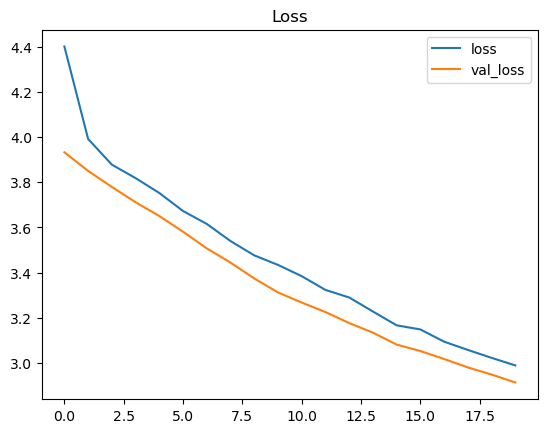

In [11]:
loss = hist.history["loss"]
val_loss = hist.history["val_loss"]

plt.plot(loss, label="loss")
plt.plot(val_loss, label="val_loss")
plt.title("Loss")
plt.legend()
plt.show()

Como se ha dicho antes el acc ha aumentado un poco más.

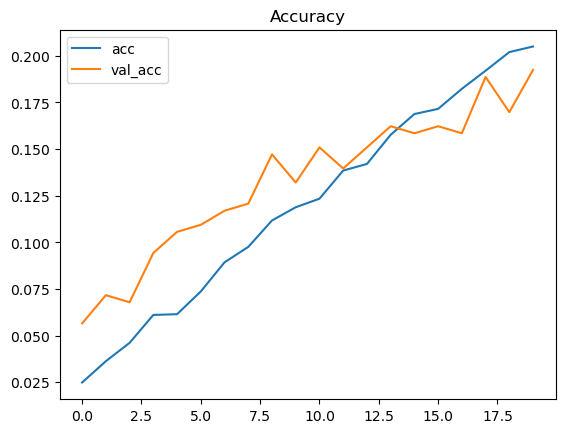

In [12]:
acc = hist.history["sparse_categorical_accuracy"]
val_acc = hist.history["val_sparse_categorical_accuracy"]

plt.plot(acc, label="acc")
plt.plot(val_acc, label="val_acc")
plt.title("Accuracy")
plt.legend()
plt.show()

El modelo funciona muy bien tanto en validación como en test, lo que indica que vamos por buen camino a la hora de crear una arquitectura buena para resolver este problema.

In [13]:

train_loss, train_acc = model.evaluate(X_train, y_train_num, verbose=0)
val_loss, val_acc = model.evaluate(X_val, y_val_num, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test_num, verbose=0)

print("TRAIN:")
print("Loss:", round(train_loss,3))
print("Accuracy:", round(train_acc,3))

print("\nVALIDATION:")
print("Loss:", round(val_loss,3))
print("Accuracy:", round(val_acc,3))

print("\nTEST:")
print("Loss:", round(test_loss,3))
print("Accuracy:", round(test_acc,3))

TRAIN:
Loss: 2.833
Accuracy: 0.307

VALIDATION:
Loss: 2.913
Accuracy: 0.192

TEST:
Loss: 2.932
Accuracy: 0.245


# Matriz de confución

Si miramos la matriz de confusión, el modelo funciona razonablemente bien, recordemos que es para detección de cartas; pero aun hay mucho margen de mejora.

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step


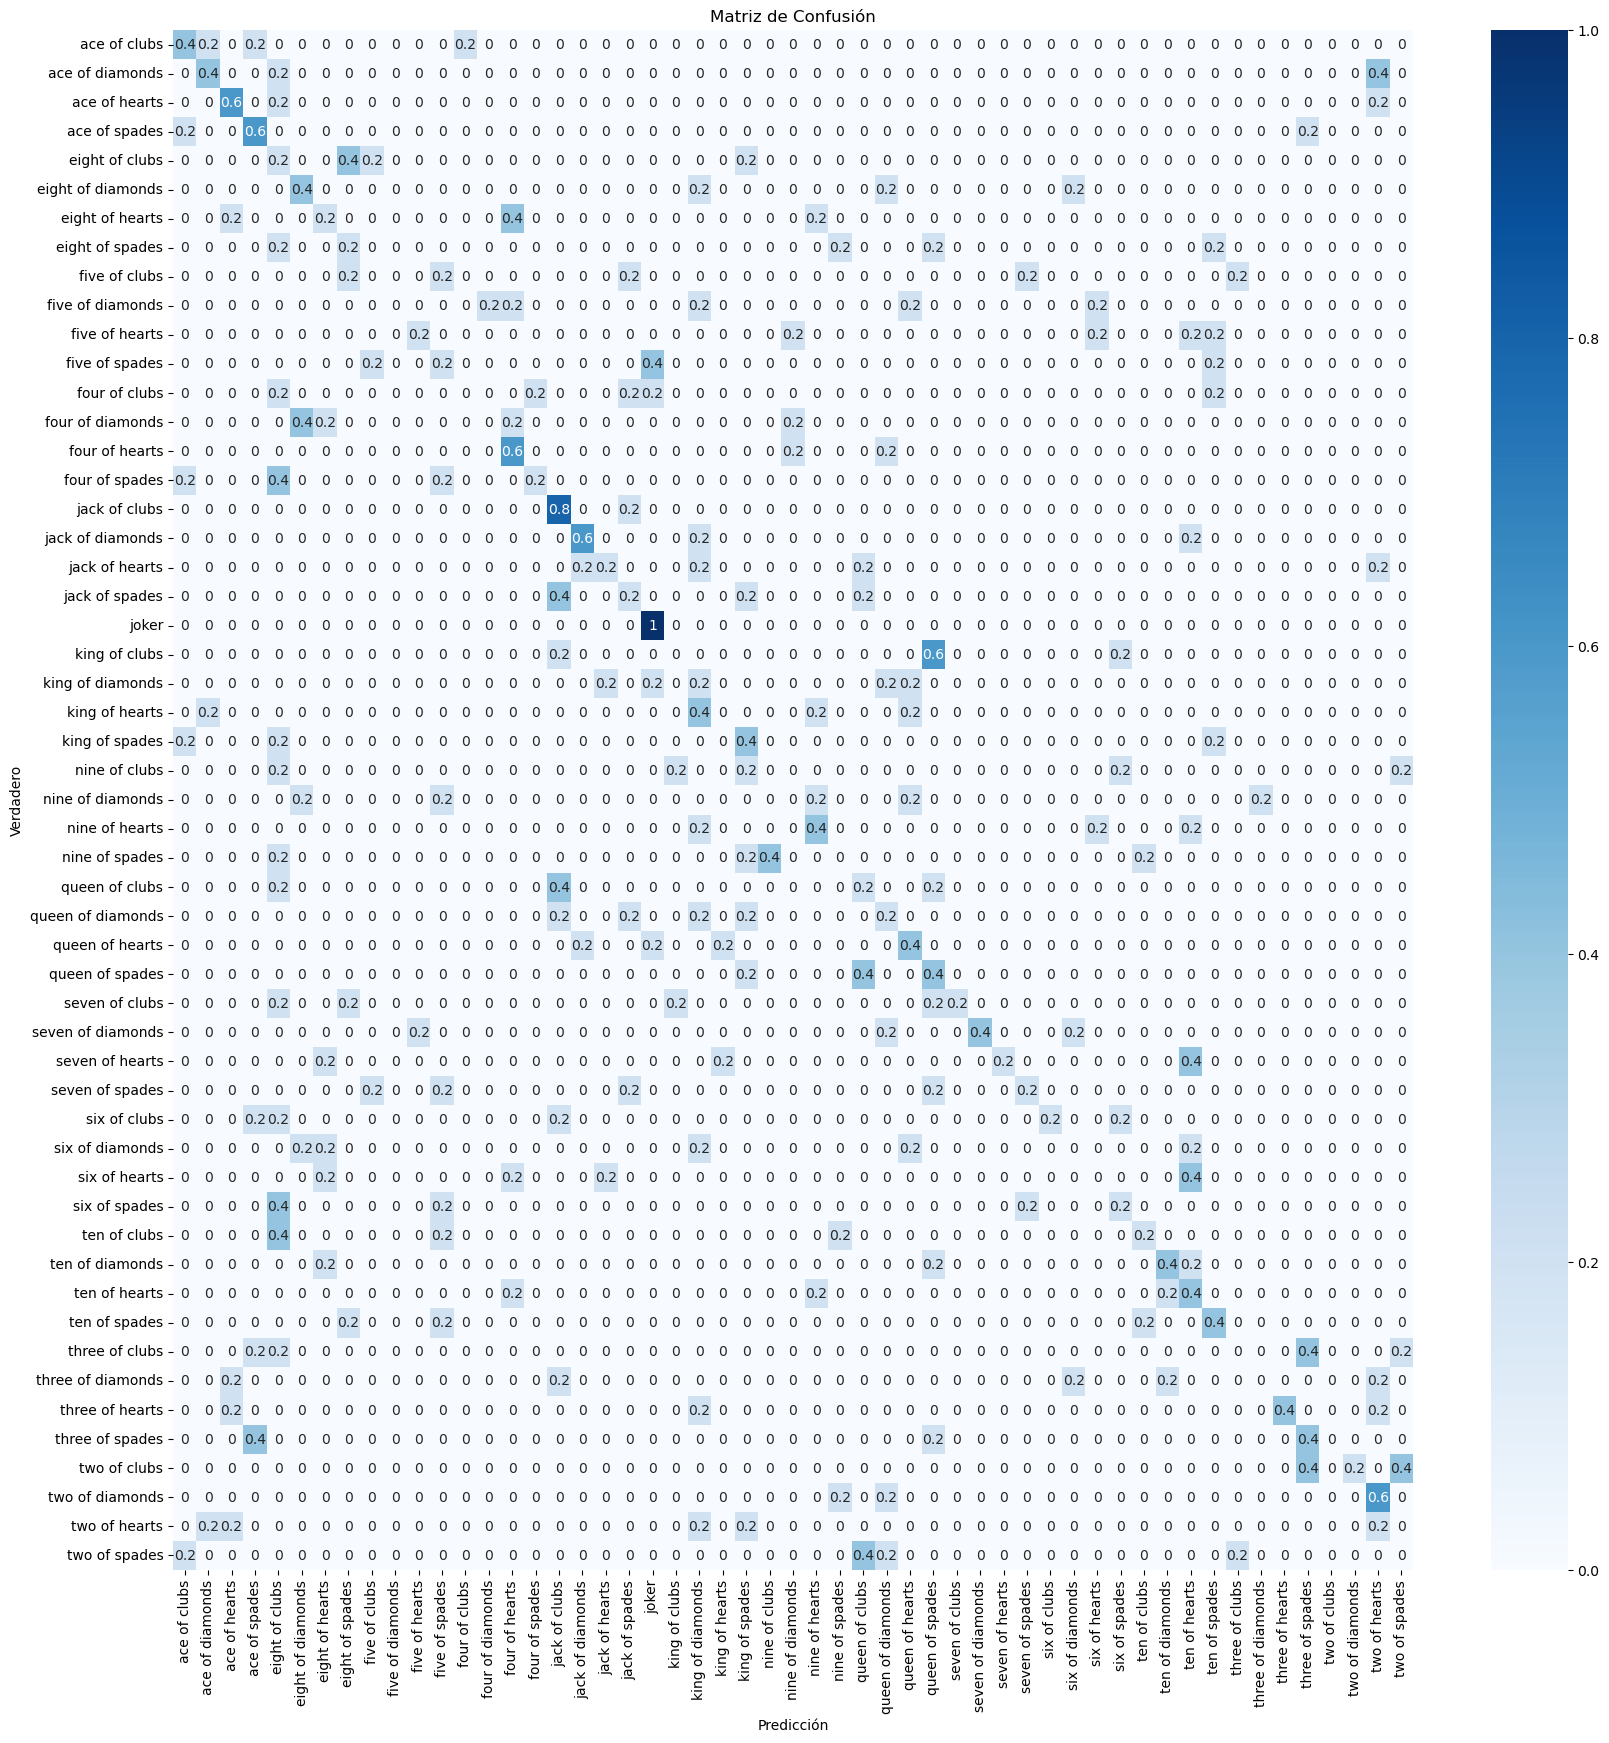

In [14]:
class_names = encoder.classes_

cm = confusion_matrix(y_test_num, np.argmax(model.predict(X_test), axis=1), normalize="true")

plt.figure(figsize=(20, 20))
sns.heatmap(cm,
            annot=True, cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar=True)

plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.title('Matriz de Confusión')
plt.yticks(rotation=0)
plt.show()

# Conclusión

El modelo aun parece tener margen de mejora, el proximo paso podría ser añadir más capas o incluso regularizar un poco más.